# 03 Exploratory Data Analysis: Count Data

This notebook is used for the exploratory data anlysis of the processed count dataset before fitting the first-stage model for normal cycling counts.

We inspect variable types, categorical variable frequencies, continuous variable distributions, and the distribution of the modelling outcome.

The outcome for the first modelling stage is the 2-hour cyclist count. The variable `count_rescaled` is used as the modelling outcome because it represents the adjusted 2-hour count after handling mostly complete intervals with some missing 15-minute observations.

## Importing packages, establishing path and reading count data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "outputs" / "diagnostics"

diagnostics_folder.mkdir(parents=True, exist_ok=True)

In [3]:
counts_model_final = pd.read_csv(
    processed_folder / "counts_model_final.csv"
)

counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


## Structure of the dataset

In [4]:
print("Rows:", counts_model_final.shape[0])
print("Columns:", counts_model_final.shape[1])

Rows: 4587736
Columns: 27


In [5]:
counts_model_final.dtypes

site_id                         int64
direction                         str
year                            int64
date                              str
month                           int64
weekday                           str
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                float64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                         str
municipality                      str
district                          str
installation_date                 str
direction_description             str
is_public_holiday               int64
holiday_name                      str
is_school_holiday               int64
school_holiday_name               str
fuel_price_p

In [6]:
pd.set_option("display.max_columns", None)
counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


In [7]:
pd.set_option("display.max_columns", None)
counts_model_final.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
4587731,152,OUT,2026,2026-04-30,4,Thursday,14,102.0,8,8,0,0.0,8,102.0,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587732,152,OUT,2026,2026-04-30,4,Thursday,16,82.0,8,8,0,0.0,8,82.0,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587733,152,OUT,2026,2026-04-30,4,Thursday,18,27.0,8,8,0,0.0,8,27.0,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587734,152,OUT,2026,2026-04-30,4,Thursday,20,17.0,8,8,0,0.0,8,17.0,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587735,152,OUT,2026,2026-04-30,4,Thursday,22,4.0,8,8,0,0.0,8,4.0,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212


Converting date variable into date format variable

In [8]:
date_columns = [
    "date",
    "installation_date",
]

for column in date_columns:
    if column in counts_model_final.columns:
        counts_model_final[column] = pd.to_datetime(
            counts_model_final[column],
            errors="coerce"
        )

## Defining variable groups

In [9]:
outcome_variable = "count_rescaled"

categorical_variables = [
    "site_id",
    "direction",
    "year",
    "month",
    "weekday",
    "hour_bin",
    "municipality",
    "district",
    "is_public_holiday",
    "holiday_name",
    "is_school_holiday",
    "school_holiday_name",
]

continuous_variables = [
    "fuel_price_petrol_95",
]

In [10]:
categorical_variables = [
    variable for variable in categorical_variables
    if variable in counts_model_final.columns
]

continuous_variables = [
    variable for variable in continuous_variables
    if variable in counts_model_final.columns
]

In [11]:
print("Categorical variables:")
print(categorical_variables)

print("\nContinuous variables:")
print(continuous_variables)

Categorical variables:
['site_id', 'direction', 'year', 'month', 'weekday', 'hour_bin', 'municipality', 'district', 'is_public_holiday', 'holiday_name', 'is_school_holiday', 'school_holiday_name']

Continuous variables:
['fuel_price_petrol_95']


## Outcome varaible distribution

In [12]:
counts_model_final[outcome_variable].describe()

count    4.587736e+06
mean     2.135952e+01
std      4.899167e+01
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+00
75%      2.100000e+01
max      8.682000e+03
Name: count_rescaled, dtype: float64

In [13]:
print("Minimum count:", counts_model_final[outcome_variable].min())
print("Maximum count:", counts_model_final[outcome_variable].max())
print("Mean count:", counts_model_final[outcome_variable].mean())
print("Median count:", counts_model_final[outcome_variable].median())
print("Share of zero counts:", (counts_model_final[outcome_variable] == 0).mean())

Minimum count: 0.0
Maximum count: 8682.0
Mean count: 21.359515080246656
Median count: 4.0
Share of zero counts: 0.2734843504508542


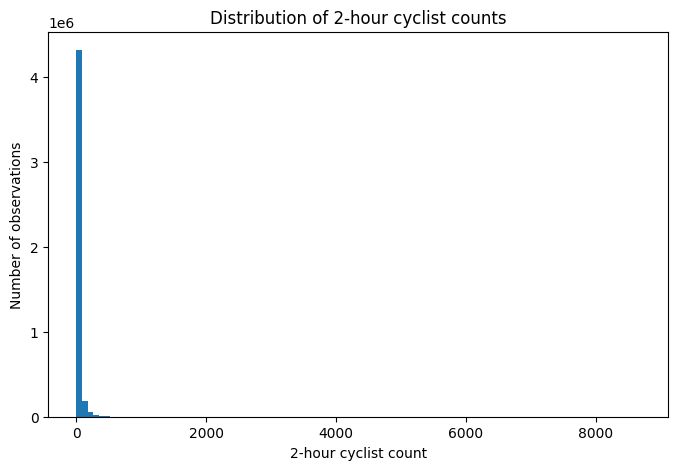

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(counts_model_final[outcome_variable], bins=100)
plt.title("Distribution of 2-hour cyclist counts")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

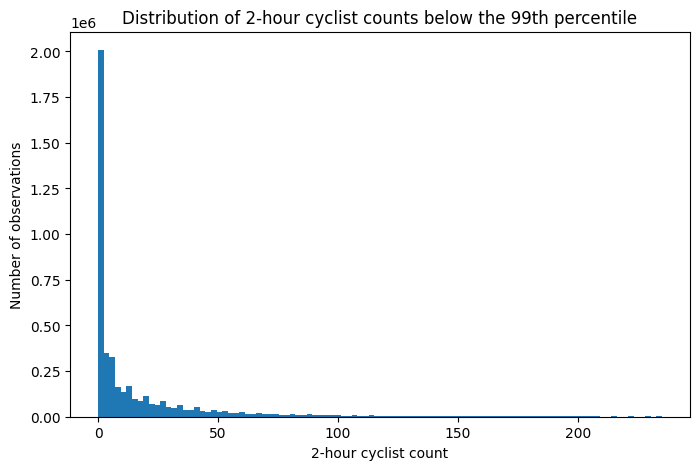

In [15]:
upper_limit = counts_model_final[outcome_variable].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    counts_model_final.loc[
        counts_model_final[outcome_variable] <= upper_limit,
        outcome_variable
    ],
    bins=100
)
plt.title("Distribution of 2-hour cyclist counts below the 99th percentile")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

In [16]:
zero_summary = (
    counts_model_final
    .assign(is_zero_count=(counts_model_final[outcome_variable] == 0).astype(int))
    .groupby(["year", "month"])
    .agg(
        observations=(outcome_variable, "size"),
        zero_counts=("is_zero_count", "sum"),
        zero_share=("is_zero_count", "mean"),
    )
    .reset_index()
)

zero_summary

,year,month,observations,zero_counts,zero_share
0,2022,5,34796,8563,0.246092
1,2022,6,45336,11503,0.253728
2,2022,7,64382,15657,0.243189
3,2022,8,79314,19365,0.244156
4,2022,9,81064,22279,0.274832
5,2022,10,92264,24689,0.267591
6,2022,11,92544,27494,0.297091
7,2022,12,95202,32288,0.339153
8,2023,1,95414,31585,0.331031
9,2023,2,88074,26006,0.295274


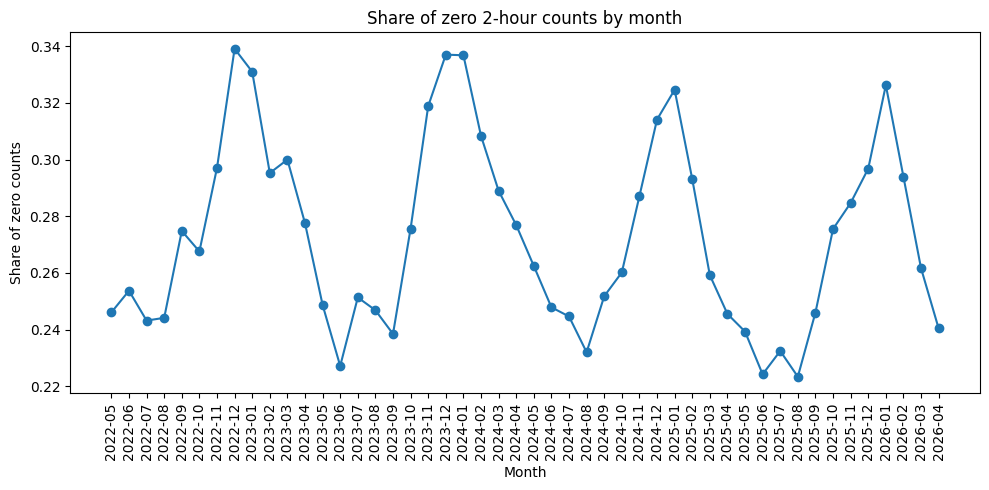

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(
    zero_summary["year"].astype(str) + "-" + zero_summary["month"].astype(str).str.zfill(2),
    zero_summary["zero_share"],
    marker="o"
)
plt.xticks(rotation=90)
plt.title("Share of zero 2-hour counts by month")
plt.xlabel("Month")
plt.ylabel("Share of zero counts")
plt.tight_layout()
plt.show()

### Overdispersion

In [18]:
outcome_mean = counts_model_final[outcome_variable].mean()
outcome_variance = counts_model_final[outcome_variable].var()

print("Mean:", outcome_mean)
print("Variance:", outcome_variance)
print("Variance-to-mean ratio:", outcome_variance / outcome_mean)

Mean: 21.359515080246656
Variance: 2400.1833963557206
Variance-to-mean ratio: 112.37068759933682


In [19]:
dispersion_by_site = (
    counts_model_final
    .groupby("site_id")
    .agg(
        mean_count=(outcome_variable, "mean"),
        variance_count=(outcome_variable, "var"),
        observations=(outcome_variable, "size"),
    )
    .reset_index()
)

dispersion_by_site["variance_to_mean_ratio"] = (
    dispersion_by_site["variance_count"] / dispersion_by_site["mean_count"]
)

dispersion_by_site = dispersion_by_site.sort_values(
    "variance_to_mean_ratio",
    ascending=False
)

pd.set_option("display.max_rows", None)
dispersion_by_site

,site_id,mean_count,variance_count,observations,variance_to_mean_ratio
139,142,190.502033,45653.920647,984,239.650570
63,64,90.386954,21648.761456,33832,239.512015
121,122,30.921309,7166.345951,31298,231.760753
138,140,82.188389,14118.409074,26236,171.781066
135,137,83.315208,13331.657842,26162,160.014698
140,143,182.752530,28653.644463,21150,156.789318
136,138,79.513472,12370.479685,26574,155.577154
106,107,185.158672,27107.597823,32330,146.401989
124,125,66.898187,9708.180155,30890,145.118733
65,66,43.862980,5794.399132,33652,132.102268


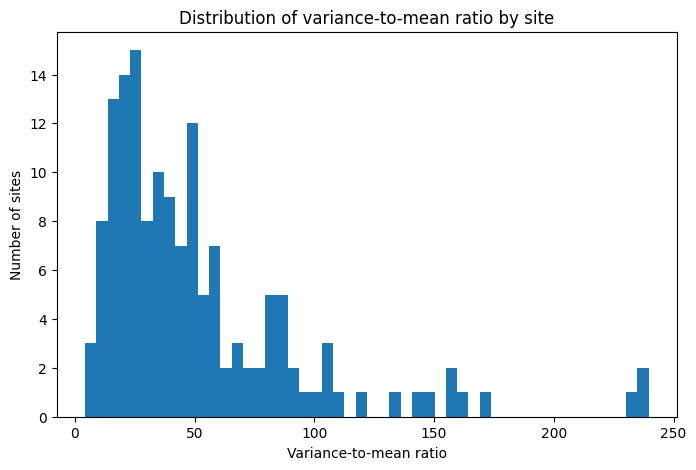

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(
    dispersion_by_site["variance_to_mean_ratio"].replace([float("inf")], pd.NA).dropna(),
    bins=50
)
plt.title("Distribution of variance-to-mean ratio by site")
plt.xlabel("Variance-to-mean ratio")
plt.ylabel("Number of sites")
plt.show()

## Categorical predictors

In [21]:
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [22]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(counts_model_final, variable).head(30))


site_id


,site_id,count,percentage
0,2,35056,0.764124
1,4,35056,0.764124
2,5,35056,0.764124
3,8,35056,0.764124
4,9,35056,0.764124
5,10,35056,0.764124
6,11,35056,0.764124
7,13,35056,0.764124
8,14,35056,0.764124
9,15,35056,0.764124



direction


,direction,count,percentage
0,IN,2293874,50.000131
1,OUT,2293862,49.999869



year


...

,holiday_name,count,percentage
0,No public holiday,4414804,96.230559
1,Good Friday,13200,0.287724
2,Easter Monday,13152,0.286677
3,All Saints' Day,13080,0.285108
4,Armistice Day,13080,0.285108
5,Christmas Day,12960,0.282492
6,St. Stephen's Day,12960,0.282492
7,New Year's Day,12954,0.282361
8,Easter Sunday,12902,0.281228
9,Assumption Day,12364,0.269501



is_school_holiday


,is_school_holiday,count,percentage
0,0,3281386,71.525171
1,1,1306350,28.474829



school_holiday_name


,school_holiday_name,count,percentage
0,No school holiday,3281386,71.525171
1,Summer Holidays,753754,16.429760
2,Spring Holidays,187858,4.094787
3,Winter Holidays,181352,3.952974
4,Carnival Holidays,91934,2.003908
5,All Saints Holidays,91452,1.993402


## Continuous predictors

In [23]:
counts_model_final[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,4587736.0,1.65791,0.116624,1.4482,1.55825,1.64865,1.71891,2.11083


In [24]:
def plot_histogram(data, variable, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

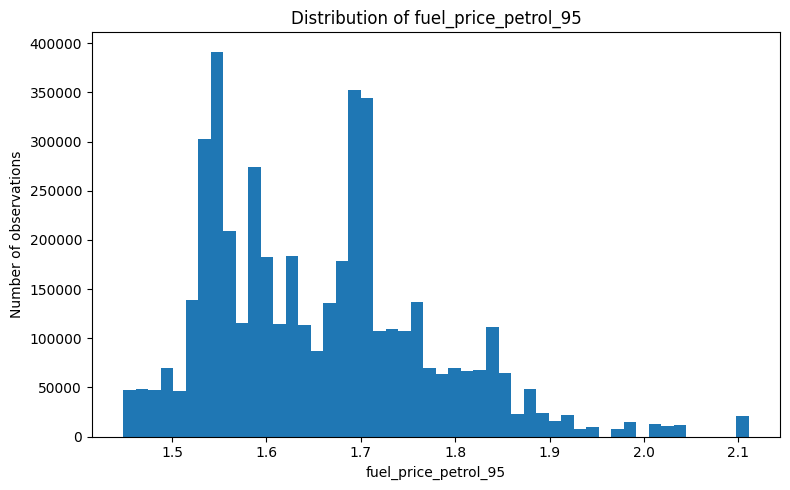

In [25]:
for variable in continuous_variables:
    plot_histogram(counts_model_final, variable)

# Site Checks

This part is to recheck the geographical information and to unify the name of locations, municipality, district, regions,... to convert to external data.

## Import libraries

In [26]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

## Exploring current location identifiers

First, we check the overall missing data. Then, we evaluate if the current site_id and site_name columns are reliable unique identifiers for our physical sensors.

In [27]:
counts_model_final.isna().sum()

site_id                           0
direction                         0
year                              0
date                              0
month                             0
weekday                           0
hour_bin                          0
count                             0
observed_intervals                0
total_intervals                   0
missing_intervals                 0
missing_share                     0
expected_intervals_for_row        0
count_rescaled                    0
rescaled                          0
longitude                         0
latitude                          0
site_name                         0
municipality                   5914
district                      27064
installation_date                 0
direction_description             0
is_public_holiday                 0
holiday_name                      0
is_school_holiday                 0
school_holiday_name               0
fuel_price_petrol_95              0
dtype: int64

Municipality and district columns include many missing values, not really valid option. 

In [28]:
# Check current site_id and site_name
unique_site_ids = counts_model_final['site_id'].unique()
unique_site_names = counts_model_final['site_name'].unique()

print(f"Total Unique site_ids: {len(unique_site_ids)}")
print(f"Total Unique site_names: {len(unique_site_names)}\n")

Total Unique site_ids: 149
Total Unique site_names: 141



=> Mismatch => Site_name no longer reliable

In [29]:
# Check unique combinations and mismatches
unique_combos = counts_model_final[['site_id', 'site_name']].drop_duplicates().sort_values(by=['site_name', 'site_id'])

# Identify IDs or Names that occur more than once
id_counts = unique_combos['site_id'].value_counts()
name_counts = unique_combos['site_name'].value_counts()

mismatched_ids = id_counts[id_counts > 1].index
mismatched_names = name_counts[name_counts > 1].index

mismatching_mask = unique_combos['site_id'].isin(mismatched_ids) | unique_combos['site_name'].isin(mismatched_names)

print(f"Total Unique (site_id, site_name) Combinations: {len(unique_combos)}")
print(f"Perfect 1-to-1 Matches: {len(unique_combos[~mismatching_mask])}")
print(f"Problematic Mismatches: {len(unique_combos[mismatching_mask])}")

if not unique_combos[mismatching_mask].empty:
    print("MISMATCHING COMBINATIONS FOUND:")
    print("This indicates sensors were moved, renamed, or IDs were reused.")
    print(unique_combos[mismatching_mask].to_string(index=False))

Total Unique (site_id, site_name) Combinations: 149
Perfect 1-to-1 Matches: 133
Problematic Mismatches: 16
MISMATCHING COMBINATIONS FOUND:
This indicates sensors were moved, renamed, or IDs were reused.
 site_id              site_name
      20                 Brugge
      52                 Brugge
      50   Brugge, Sint-Andries
      51   Brugge, Sint-Andries
      98          Geel teller 2
     112          Geel teller 2
     137 Hasselt-Kempische brug
     138 Hasselt-Kempische brug
      30           Herk De Stad
      31           Herk De Stad
      32                 Lummen
      33                 Lummen
       1               Machelen
     149               Machelen
     145               Overijse
     147               Overijse


I'll just save the mismatches here and run it again on the final dataset for deviations to see if we need to mention them in the report (Quite small number and I think they're just 2 different sites at the same location).

## Shift to Coordinates

Since the manual names and IDs contain mismatches, we need a better way to define locations. We will use the exact GPS coordinates (Latitude & Longitude) to verify where these sensors actually are.

### Initial analysis

In [30]:
# Create a combined string column for the exact coordinate pair
counts_model_final['coord_combo'] = counts_model_final['latitude'].astype(str) + ", " + counts_model_final['longitude'].astype(str)

unique_coords_count = counts_model_final['coord_combo'].nunique()
print(f"Total unique physical locations (coordinates): {unique_coords_count}\n")

# Isolate unique combinations of ID, Name, and Coordinates to see how they interact
unique_locs = counts_model_final[['site_id', 'site_name', 'coord_combo']].drop_duplicates()

print("MISMATCH ANALYSIS (COORDS VS IDs)")
# 1. Check if one coordinate has multiple site_ids (Co-located sensors)
coord_ids_count = unique_locs.groupby('coord_combo')['site_id'].nunique()
mismatched_coords = coord_ids_count[coord_ids_count > 1]

if not mismatched_coords.empty:
    print("One Coordinate with Multiple IDs (Sensors at the exact same spot):")
    print(unique_locs[unique_locs['coord_combo'].isin(mismatched_coords.index)].sort_values('coord_combo').to_string(index=False))

# 2. Check if one site_name has multiple coordinates (Same name used in different places)
name_coords_count = unique_locs.groupby('site_name')['coord_combo'].nunique()
mismatched_names = name_coords_count[name_coords_count > 1]

if not mismatched_names.empty:
    print("One Name with Multiple Coordinates (Name re-used in different places):")
    print(unique_locs[unique_locs['site_name'].isin(mismatched_names.index)].sort_values('site_name').to_string(index=False))

Total unique physical locations (coordinates): 147

MISMATCH ANALYSIS (COORDS VS IDs)
One Coordinate with Multiple IDs (Sensors at the exact same spot):
 site_id                         site_name           coord_combo
     116                    Melle teller 2 50.9986113, 3.8040599
     117                    Melle teller 1 50.9986113, 3.8040599
      52                            Brugge     51.22632, 3.24095
     142 TEST Validatie BRUGGE Y2H22022134     51.22632, 3.24095
One Name with Multiple Coordinates (Name re-used in different places):
 site_id              site_name                          coord_combo
      20                 Brugge                    51.17416, 3.20048
      52                 Brugge                    51.22632, 3.24095
      50   Brugge, Sint-Andries                    51.19291, 3.16252
      51   Brugge, Sint-Andries                    51.19281, 3.16252
      98          Geel teller 2                     51.1481, 4.99643
     112          Geel teller 2      

149 IDs vs. 147 combos => 2 mismatch cases => Much smaller problem.

### Recoding Locations via Geopy

In [31]:
# Extract only the unique coordinates to minimize API calls
unique_locations = counts_model_final[['latitude', 'longitude']].drop_duplicates().dropna().copy()
print(f"Fetching mapping data for {len(unique_locations)} unique points...")

# Setup API
geolocator = Nominatim(user_agent="belgium_traffic_mapper_final")
reverse_geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_admin_levels(row):
    coord_str = f"{row['latitude']}, {row['longitude']}"
    try:
        location = reverse_geocode(coord_str, exactly_one=True, language='en')
        address = location.raw.get('address', {})
        
        muni = address.get('municipality') or address.get('town') or address.get('city') or address.get('village') or "Unknown"
        prov = address.get('state', 'Unknown')
        reg = address.get('region', 'Unknown')
        
        return pd.Series([muni, prov, reg])
    except:
        return pd.Series(["Error", "Error", "Error"])

# Apply the function
unique_locations[['geopy_municipality', 'geopy_province', 'geopy_region']] = unique_locations.apply(get_admin_levels, axis=1)

# Clean up "Province of" text
unique_locations['geopy_province'] = unique_locations['geopy_province'].str.replace('Province of ', '', regex=False)

# Antwerp -> Antwerp Region to distinguish from the city of Antwerp
unique_locations['geopy_province'] = unique_locations['geopy_province'].replace('Antwerp', 'Antwerp Region')

# Merge back to the massive main dataset
counts_model_adding_geopy = counts_model_final.merge(unique_locations, on=['latitude', 'longitude'], how='left')

Fetching mapping data for 147 unique points...


In [32]:
# Check results of geopy mapping
print(counts_model_adding_geopy['geopy_region'].value_counts(dropna=False))
print(counts_model_adding_geopy['geopy_province'].value_counts(dropna=False))
print(counts_model_adding_geopy['geopy_municipality'].value_counts(dropna=False))

geopy_region
Unknown             4581822
Brussels-Capital       5914
Name: count, dtype: int64
geopy_province
Flemish Brabant    1090976
Limburg             940071
West Flanders       933696
Antwerp Region      890010
East Flanders       727069
Unknown               5914
Name: count, dtype: int64
geopy_municipality
Laakdal                         330724
Heusden-Zolder                  251463
Bruges                          196166
Kortrijk                        157970
Nieuwpoort                      135124
Malle                           131248
Aalst                           105168
Hamont-Achel                    105168
Tienen                          105004
Maasmechelen                    103588
Leuven                           99274
Heverlee                         70446
Heist-op-den-Berg                70112
Ostend                           70112
Lommel                           70112
Maaseik                          70112
Pelt                             70112
Brasschaat          

The Unknown counts of region is the Brussel => Refining next step. 

### Refining Geographic Regions

In [33]:
# Dictionary mapping the 5 Flemish provinces to the Flanders region
province_to_region = {
    'Antwerp Region': 'Flanders',
    'East Flanders': 'Flanders',
    'Flemish Brabant': 'Flanders',
    'Limburg': 'Flanders',
    'West Flanders': 'Flanders'
}

# 1. Fill in 'Flanders' for any row that has one of the 5 provinces
counts_model_adding_geopy['geopy_region'] = counts_model_adding_geopy['geopy_province'].map(province_to_region).fillna(counts_model_adding_geopy['geopy_region'])

# 2. Fix Brussels (Set province to 'Brussels' where region is 'Brussels-Capital')
counts_model_adding_geopy.loc[counts_model_adding_geopy['geopy_region'] == 'Brussels-Capital', 'geopy_province'] = 'Brussels'

# Check the final cleaned results
print(counts_model_adding_geopy['geopy_region'].value_counts(dropna=False))
print(counts_model_adding_geopy['geopy_province'].value_counts(dropna=False))
print(counts_model_adding_geopy['geopy_municipality'].value_counts(dropna=False))

geopy_region
Flanders            4581822
Brussels-Capital       5914
Name: count, dtype: int64
geopy_province
Flemish Brabant    1090976
Limburg             940071
West Flanders       933696
Antwerp Region      890010
East Flanders       727069
Brussels              5914
Name: count, dtype: int64
geopy_municipality
Laakdal                         330724
Heusden-Zolder                  251463
Bruges                          196166
Kortrijk                        157970
Nieuwpoort                      135124
Malle                           131248
Aalst                           105168
Hamont-Achel                    105168
Tienen                          105004
Maasmechelen                    103588
Leuven                           99274
Heverlee                         70446
Heist-op-den-Berg                70112
Ostend                           70112
Lommel                           70112
Maaseik                          70112
Pelt                             70112
Brasschaat          

In [34]:
pd.set_option("display.max_rows", None)
counts_model_adding_geopy.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
5,1,IN,2022,2022-05-01,5,Sunday,10,28.0,8,8,0,0.0,8,28.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
6,1,IN,2022,2022-05-01,5,Sunday,12,22.0,8,8,0,0.0,8,22.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
7,1,IN,2022,2022-05-01,5,Sunday,14,32.0,8,8,0,0.0,8,32.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
8,1,IN,2022,2022-05-01,5,Sunday,16,20.0,8,8,0,0.0,8,20.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders
9,1,IN,2022,2022-05-01,5,Sunday,18,8.0,8,8,0,0.0,8,8.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders


# Create 2025-2026 Dataset

Here I recreate new set for our deviations detecting step, which concludes data from 01-05-2025 to 30-04-2026.

## Date Range Resetting

First, rerange the new dataset + initial count analysis

In [35]:
# Ensure the date column is in a proper datetime format for safe comparison
counts_model_adding_geopy['date'] = pd.to_datetime(counts_model_adding_geopy['date'])

start_date = pd.to_datetime('2025-05-01')
end_date = pd.to_datetime('2026-04-30')

# Split the data into historical (training) and the new 2025-2026 period
historical_data = counts_model_adding_geopy[counts_model_adding_geopy['date'] < start_date]
data_20252026 = counts_model_adding_geopy[(counts_model_adding_geopy['date'] >= start_date) & (counts_model_adding_geopy['date'] <= end_date)]

print(f"Rows in Historical Data (Before May 2025): {len(historical_data)}")
print(f"Rows in 2025-2026 Data: {len(data_20252026)}\n")

Rows in Historical Data (Before May 2025): 3361867
Rows in 2025-2026 Data: 1225869



## Site analysis

There might be some new created site during this period. My suggestion is to drop out all of them since we cannot predict their behaviors without past data.

In [36]:
# Get unique site IDs for both periods
historical_sites = set(historical_data['site_id'].unique())
target_sites = set(data_20252026['site_id'].unique())

# Find newly created sites (Sites in target_sites that are NOT in historical_sites)
new_sites = target_sites - historical_sites

print(f"Total unique sites trained on (Historical): {len(historical_sites)}")
print(f"Total unique sites active in 2025-2026: {len(target_sites)}")
print(f"Number of BRAND NEW sites to drop: {len(new_sites)}")

if len(new_sites) > 0:
    print(f"Site IDs being dropped because they are new: {list(new_sites)}\n")
else:
    print("No new sites found. All sites in 2025-2026 were present in the historical data.\n")

Total unique sites trained on (Historical): 141
Total unique sites active in 2025-2026: 144
Number of BRAND NEW sites to drop: 8
Site IDs being dropped because they are new: [np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]



So basically, all the site with IDs from 145 to 152 (the highest number) are new ones. We exclude them in our analysis.

In [37]:
# Filter the 2025-2026 data to only include rows where the site_id exists in our historical training set
data_20252026_clean = data_20252026[data_20252026['site_id'].isin(historical_sites)].copy()

# Print the final summary to confirm the drop was successful
original_rows = len(data_20252026)
rows_dropped = original_rows - len(data_20252026_clean)

print(f"Original rows in 2025-2026: {original_rows}")
print(f"Rows remaining after dropping new sites: {len(data_20252026_clean)}")
print(f"Total rows dropped: {rows_dropped}")
print(f"Percentage of data dropped: {(rows_dropped / original_rows)*100:.2f}%")
print(f"Final number of valid unique sites: {data_20252026_clean['site_id'].nunique()}")

Original rows in 2025-2026: 1225869
Rows remaining after dropping new sites: 1177575
Total rows dropped: 48294
Percentage of data dropped: 3.94%
Final number of valid unique sites: 136


Under 5% of the original dataset to exclude => Possible

## Adding events

### Import libraries and load external data

In [38]:
!pip install openpyxl

In [39]:
event_data_path = project_folder / "data" / "external" / "Special_events.xlsx"

In [40]:
# Load the sheets into separate dataframes by their names
strikes = pd.read_excel(event_data_path, sheet_name='transport_strike')
outdoor_music_events = pd.read_excel(event_data_path, sheet_name='music_event')
indoor_music_events = pd.read_excel(event_data_path, sheet_name='indoor_music_event')
sport_events = pd.read_excel(event_data_path, sheet_name='major_sport_event')

### Adding strikes columns

In [41]:
strikes.head()

,event,date,location
0,De Lijn strike,2025-05-20,Flanders
1,SNCB-NMBS,2025-05-20,national
2,SNCB-NMBS,2025-11-24,national
3,SNCB-NMBS,2025-11-25,national
4,SNCB-NMBS,2025-11-26,national


In [42]:
# Make sure both date columns are actual datetime objects so they match perfectly
data_20252026_clean['date'] = pd.to_datetime(data_20252026_clean['date'])
strikes['date'] = pd.to_datetime(strikes['date'])

# Initialize the new column with 0 (False / No Strike)
data_20252026_clean['is_strike'] = 0

In [43]:
# Loop through each strike event and update the 'is_strike' column accordingly
for index, row in strikes.iterrows():
    strike_date = row['date']
    strike_loc = str(row['location']).strip() 
    
    # Condition 1: Date
    date_mask = data_20252026_clean['date'] == strike_date
    
    # Condition 2: Region
    if strike_loc.lower() == 'national':
        # If it's national, update all regions to 1 for that date
        data_20252026_clean.loc[date_mask, 'is_strike'] = 1
    elif strike_loc.lower() == 'flanders':
        # If it's Flanders, update rows where geopy_region is 'Flanders'
        region_mask = data_20252026_clean['geopy_region'] == 'Flanders'
        data_20252026_clean.loc[date_mask & region_mask, 'is_strike'] = 1
    else:
        region_mask = data_20252026_clean['geopy_province'] == strike_loc
        data_20252026_clean.loc[date_mask & region_mask, 'is_strike'] = 1

In [44]:
pd.set_option("display.max_columns", None)
data_20252026_clean.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,is_strike
13142,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13143,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13144,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13145,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13146,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13147,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,0,0.0,8,28.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13148,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13149,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,0,0.0,8,45.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13150,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0
13151,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0


In [45]:
# Check how many rows were marked as strikes vs non-strikes
strike_counts = data_20252026_clean['is_strike'].value_counts()
print(f"Normal days (0): {strike_counts.get(0, 0)}")
print(f"Strike days (1): {strike_counts.get(1, 0)}")

Normal days (0): 1129175
Strike days (1): 48400


Under 5% of strike dates. => Kinda skewed 

In [46]:
sample_check = counts_model_adding_geopy[counts_model_adding_geopy['date'] == '20-05-2025']
sample_check[['date', 'geopy_province']].head()


,date,geopy_province
13370,2025-05-20,Flemish Brabant
13371,2025-05-20,Flemish Brabant
13372,2025-05-20,Flemish Brabant
13373,2025-05-20,Flemish Brabant
13374,2025-05-20,Flemish Brabant


In [47]:
# Sample check
sample_strike = data_20252026_clean[data_20252026_clean['date'] == '20-05-2025']
if not sample_strike.empty:
    print("\n--- SAMPLE: 2025-05-20 (National Strike) ---")
    print(sample_strike[['date', 'geopy_province', 'is_strike']].head())


--- SAMPLE: 2025-05-20 (National Strike) ---
            date   geopy_province  is_strike
13370 2025-05-20  Flemish Brabant          1
13371 2025-05-20  Flemish Brabant          1
13372 2025-05-20  Flemish Brabant          1
13373 2025-05-20  Flemish Brabant          1
13374 2025-05-20  Flemish Brabant          1


=> Result matched.

### Adding music events columns

**Outdoor events**

In [48]:
outdoor_music_events.head()

,event name,event type,date,location,time,start_time,end_time
0,Tomorrowland Belgium 2025,music festival,2025-07-18,Boom,whole day,00:00:00,23:59:00
1,Tomorrowland Belgium 2025,music festival,2025-07-19,Boom,whole day,00:00:00,23:59:00
2,Tomorrowland Belgium 2025,music festival,2025-07-20,Boom,whole day,00:00:00,23:59:00
3,Tomorrowland Belgium 2025,music festival,2025-07-25,Boom,whole day,00:00:00,23:59:00
4,Tomorrowland Belgium 2025,music festival,2025-07-26,Boom,whole day,00:00:00,23:59:00


In [49]:
# Ensure the date columns are datetime objects
outdoor_music_events['date'] = pd.to_datetime(outdoor_music_events['date'])

# Initialize the new columns
data_20252026_clean['is_outdoor_music'] = 0
data_20252026_clean['outdoor_music_event_type'] = "None"  # Default to "None" for normal days

In [50]:
# Loop through each outdoor music event and update the corresponding columns
for index, row in outdoor_music_events.iterrows():
    # 1. Extract Event Information
    event_date = row['date']
    loc = str(row['location']).strip()
    
    current_event_type = str(row['event type']).strip() 
    
    # 2. Safely parse the start and end times to get the hour (0-23)
    try:
        start_hour = pd.to_datetime(str(row['start_time'])).hour
        end_hour = pd.to_datetime(str(row['end_time'])).hour
        
        if end_hour < start_hour:
            end_hour = 24
    except:
        continue

    # 3. Checking the 3 Conditions
    date_mask = (data_20252026_clean['date'] == event_date)
    loc_mask = (data_20252026_clean['geopy_municipality'] == loc) | (data_20252026_clean['geopy_province'] == loc)
    time_mask = (data_20252026_clean['hour_bin'] <= end_hour) & ((data_20252026_clean['hour_bin'] + 2) > start_hour)
    
    # The combined mask where ALL conditions are True
    final_match_mask = date_mask & loc_mask & time_mask
    
    # Update BOTH columns for the matching rows!
    data_20252026_clean.loc[final_match_mask, 'is_outdoor_music'] = 1
    data_20252026_clean.loc[final_match_mask, 'outdoor_music_event_type'] = current_event_type

In [51]:
pd.set_option("display.max_columns", None)
data_20252026_clean.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,is_strike,is_outdoor_music,outdoor_music_event_type
13142,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13143,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13144,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13145,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13146,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13147,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,0,0.0,8,28.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13148,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13149,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,0,0.0,8,45.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13150,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None
13151,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None


In [52]:
# Check results
music_counts = data_20252026_clean['is_outdoor_music'].value_counts()
print(f"Normal traffic intervals (0): {music_counts.get(0, 0)}")
print(f"Music event intervals (1): {music_counts.get(1, 0)}")

type_counts = data_20252026_clean['outdoor_music_event_type'].value_counts()
print(type_counts)

Normal traffic intervals (0): 1174175
Music event intervals (1): 3400
outdoor_music_event_type
None                         1174175
music festival                  1960
theatre/cultural festival        528
cultural city festival           480
cultural parade                  216
city music festival               72
arts/music festival               72
food/cultural event               72
Name: count, dtype: int64


**Indoor music events**

In [53]:
indoor_music_events.head()

,event name,event type,date,location,time,start_time,end_time
0,Tate McRae - Miss Possessive Tour,indoor concert,2025-05-14,Antwerp,18:00-23:59,18:00:00,23:59:00
1,Dotan + Iskander Moon,indoor concert,2025-05-21,Leuven,18:00-23:59,18:00:00,23:59:00
2,The Music of The Lord of the Rings & The Hobbi...,indoor orchestral concert,2025-05-26,Hasselt,18:00-23:00,18:00:00,23:00:00
3,Lords Of The Sound,indoor orchestral concert,2025-06-05,Hasselt,18:00-23:00,18:00:00,23:00:00
4,Dua Lipa - Radical Optimism Tour,indoor concert,2025-06-11,Antwerp,18:00-23:59,18:00:00,23:59:00


In [54]:
# Ensure the date columns are datetime objects
indoor_music_events['date'] = pd.to_datetime(indoor_music_events['date'])

# Initialize the new columns
data_20252026_clean['is_indoor_music'] = 0
data_20252026_clean['indoor_music_event_type'] = "None"  # Default to "None" for normal days

In [55]:
# Loop through each indoor music event and update the corresponding columns
for index, row in indoor_music_events.iterrows():
    # 1. Extract Event Information
    event_date = row['date']
    loc = str(row['location']).strip()
    
    current_event_type = str(row['event type']).strip() 
    
    # 2. Safely parse the start and end times to get the hour (0-23)
    try:
        start_hour = pd.to_datetime(str(row['start_time'])).hour
        end_hour = pd.to_datetime(str(row['end_time'])).hour
        
        if end_hour < start_hour:
            end_hour = 24
    except:
        continue

    # 3. Checking the 3 Conditions
    date_mask = (data_20252026_clean['date'] == event_date)
    loc_mask = (data_20252026_clean['geopy_municipality'] == loc) | (data_20252026_clean['geopy_province'] == loc)
    time_mask = (data_20252026_clean['hour_bin'] <= end_hour) & ((data_20252026_clean['hour_bin'] + 2) > start_hour)
    
    # The combined mask where ALL conditions are True
    final_match_mask = date_mask & loc_mask & time_mask
    
    # Update BOTH columns for the matching rows!
    data_20252026_clean.loc[final_match_mask, 'is_indoor_music'] = 1
    data_20252026_clean.loc[final_match_mask, 'indoor_music_event_type'] = current_event_type

In [56]:
pd.set_option("display.max_columns", None)
data_20252026_clean.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type
13142,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13143,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13144,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13145,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13146,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13147,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,0,0.0,8,28.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13148,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13149,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,0,0.0,8,45.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13150,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None
13151,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None


In [57]:
# Check results
indoor_music_counts = data_20252026_clean['is_indoor_music'].value_counts()
print(f"Normal traffic intervals (0): {indoor_music_counts.get(0, 0)}")
print(f"Music event intervals (1): {indoor_music_counts.get(1, 0)}")

type_counts = data_20252026_clean['indoor_music_event_type'].value_counts()
print(type_counts)

Normal traffic intervals (0): 1177287
Music event intervals (1): 288
indoor_music_event_type
None                         1177287
indoor concert                   150
indoor music festival             54
indoor electronic concert         48
indoor orchestral concert         24
musical concert/show              12
Name: count, dtype: int64


### Adding sport events columns

In [58]:
sport_events.head()

,event,event type,date,location
0,Antwerp Port Epic / Sels Trophy 2025,road cycling race,2025-06-09,Antwerp
1,100KM Dodentocht 2025,mass walking event,2025-08-08,Bornem
2,Renewi Tour 2025 - Stage 3,road cycling stage race,2025-08-22,Aalter
3,Renewi Tour 2025 - Stage 3,road cycling stage race,2025-08-22,Geraardsbergen
4,Renewi Tour 2025 - Final Stage,road cycling stage race,2025-08-24,Leuven


In [59]:
# Ensure the date columns are datetime objects
sport_events['date'] = pd.to_datetime(sport_events['date'])

# Initialize the new columns
data_20252026_clean['is_sport_event'] = 0
data_20252026_clean['sport_event_type'] = "None"  # Default to "None"

In [60]:
# Loop through each sport event and update the corresponding columns
for index, row in sport_events.iterrows():
    # 1. Extract Event Information
    event_date = row['date']
    loc = str(row['location']).strip()
    
    current_event_type = str(row['event type']).strip() 

    # 2. Check conditions
    date_mask = (data_20252026_clean['date'] == event_date)
    loc_mask = (data_20252026_clean['geopy_municipality'] == loc) | (data_20252026_clean['geopy_province'] == loc)
    
    # The combined mask where BOTH conditions are True
    final_match_mask = date_mask & loc_mask
    
    # Update BOTH columns for the matching rows!
    data_20252026_clean.loc[final_match_mask, 'is_sport_event'] = 1
    data_20252026_clean.loc[final_match_mask, 'sport_event_type'] = current_event_type

In [61]:
pd.set_option("display.max_columns", None)
data_20252026_clean.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
13142,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13143,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13144,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13145,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13146,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13147,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,0,0.0,8,28.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13148,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13149,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,0,0.0,8,45.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13150,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,0,0.0,8,26.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None
13151,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,0,0.0,8,19.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,0,0,None,0,None,0,None


In [62]:
# Check results
# Check how many rows were marked as events vs normal periods
sport_counts = data_20252026_clean['is_sport_event'].value_counts()
print(f"Normal traffic intervals (0): {sport_counts.get(0, 0)}")
print(f"Sports event intervals (1): {sport_counts.get(1, 0)}")

type_counts = data_20252026_clean['sport_event_type'].value_counts()
print(type_counts)

Normal traffic intervals (0): 1175971
Sports event intervals (1): 1604
sport_event_type
None                           1175971
cycling participation event        648
cyclocross race                    432
road cycling race                  264
cyclocross world cup               120
road cycling stage race             96
running event                       44
Name: count, dtype: int64


In [63]:
output_path = processed_folder / "data_20252026_clean.csv"
data_20252026_clean.to_csv(output_path, index=False)
print(f"Saved 2025-2026 clean dataset to {output_path}")

Saved 2025-2026 clean dataset to ..\data\processed\data_20252026_clean.csv
